<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Curso: Machine Learning</p>

<p style="text-align: center;"> Código Curso: 203008067 </p>

<p style="text-align: center;"> Grupo: 03 </p>

<p style="text-align: center;"> Fase 3 - Componente práctico</p>

<p style="text-align: center;">  Presentado por: Wilmer Ricardo Urda</p>

<p style="text-align: center;"> Código: 101719427</p>

<p style="text-align: center;">  Tutor(a): Rafael Gaitan </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> 2026</p>

#EJERCICIO 1: K-MEANS CLUSTERING

##BUPA liver disorders

###a. Limpieza de datos (NaN, outliers, estandarización)

In [40]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

# =========================
# CARGAR DATASET
# =========================
dfr = fetch_openml(data_id=8, parser='auto')
df = dfr.frame.copy()

# =========================
# LIMPIEZA
# =========================

# eliminar nulos
df = df.dropna()

# eliminar columna objetivo si existe
if 'selector' in df.columns:
    df = df.drop(columns=['selector'])

# eliminar outliers (IQR)
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

# =========================
# ESTANDARIZACIÓN
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Shape final:", df.shape)

Shape final: (264, 6)


###b. ¿Cuántos clúster seleccionar?

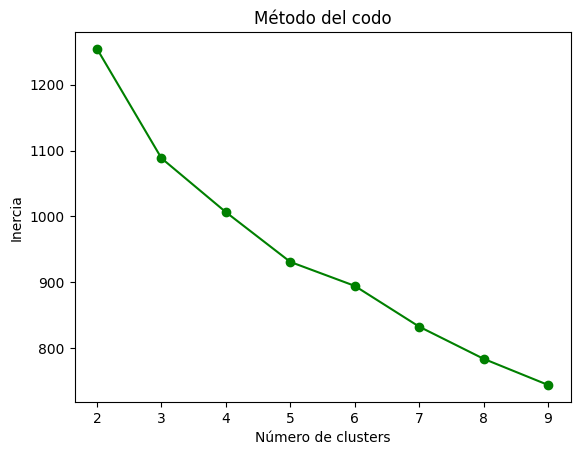

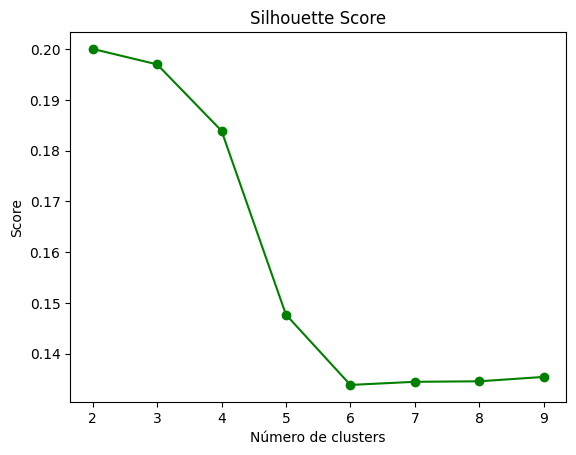

In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

# Gráfica codo
plt.plot(K_range, inertia, marker='o', color='Green')
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

# Gráfica silhouette
plt.plot(K_range, silhouette, marker='o', color='Green')
plt.title("Silhouette Score")
plt.xlabel("Número de clusters")
plt.ylabel("Score")
plt.show()

El número adecuado de clústeres se determinó mediante el método del codo y el índice de Silhouette, identificando que el valor óptimo es k = 3, ya que presenta un equilibrio entre la reducción de la inercia y una buena separación entre clústeres.

##c. ¿Con qué criterios se determina K?

Se utilizaron dos criterios principales:

Método del codo: permite identificar el punto donde la disminución de la inercia deja de ser significativa.
Silhouette Score: mide la cohesión interna y separación entre clústeres, seleccionando el valor de k que maximiza este indicador.

##d. Scatterplot con 2 variables

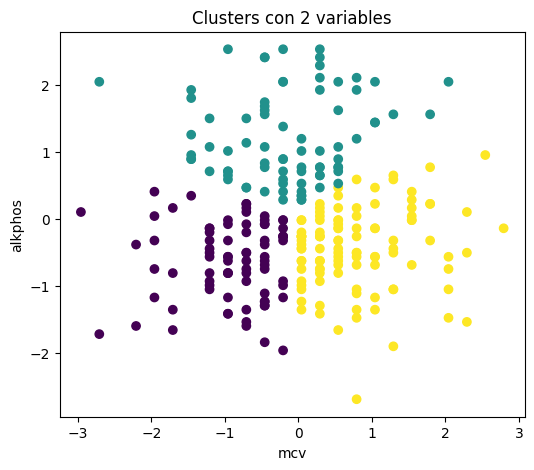

In [42]:
# seleccionar 2 variables
X_2 = df[['mcv', 'alkphos']]

scaler = StandardScaler()
X_2_scaled = scaler.fit_transform(X_2)

# modelo final
kmeans_2 = KMeans(n_clusters=3, random_state=42)
labels_2 = kmeans_2.fit_predict(X_2_scaled)

# gráfica
plt.figure(figsize=(6,5))
plt.scatter(X_2_scaled[:,0], X_2_scaled[:,1], c=labels_2, cmap='viridis')
plt.xlabel("mcv")
plt.ylabel("alkphos")
plt.title("Clusters con 2 variables")
plt.show()

Este gráfico muestra un clustering con K-Means (k=3) usando dos variables: mcv (eje X) y alkphos (eje Y), ambas estandarizadas. Aquí tienes un análisis breve y claro:

Separación principal por mcv: Los clusters se distinguen bastante bien horizontalmente.
A la izquierda (mcv bajo) → puntos morados.
En el centro (mcv medio) → puntos verdes.
A la derecha (mcv alto) → puntos amarillos.
alkphos aporta variación vertical: Dentro de cada cluster hay dispersión en alkphos, pero no define tanto la separación como mcv.
Cluster central (verde): Tiende a valores más altos de alkphos en promedio, lo que sugiere un subgrupo con niveles elevados en esa variable.
Solapamiento moderado: Especialmente entre el cluster central y los otros, lo que indica que la separación no es perfecta (algo esperado con solo 2 variables).

##SEGUNDA PARTE (más variables)

###e. ¿Mejora al usar más variables?

In [43]:
# usar todas las variables
kmeans_full = KMeans(n_clusters=3, random_state=42)
labels_full = kmeans_full.fit_predict(X_scaled)

sil_2 = silhouette_score(X_2_scaled, labels_2)
sil_full = silhouette_score(X_scaled, labels_full)

print("Silhouette (2 variables):", sil_2)
print("Silhouette (todas las variables):", sil_full)

Silhouette (2 variables): 0.35634152742629815
Silhouette (todas las variables): 0.19699082720878525


Al comparar los resultados obtenidos se observa que el modelo construido con **dos variables** (mcv y alkphos) alcanzó un Silhouette Score de **0.356**, mientras que el modelo con todas las variables numéricas obtuvo **0.197**. Dado que un valor más alto indica mayor cohesión interna y mejor separación entre grupos, se concluye que **incrementar el número de variables no mejora la agrupación** para este dataset.

Este resultado puede explicarse por la naturaleza del dataset BUPA: las variables hepáticas tienen escalas y distribuciones muy distintas, lo que genera ruido al añadir más dimensiones (maldición de la dimensionalidad). Por tanto, el modelo con 2 variables es el más adecuado y se usará para el perfilamiento de clústeres.

##PERFILAMIENTO DE CLUSTERS

In [44]:
# Se usa el mejor modelo (2 variables, Silhouette 0.356)
df['cluster'] = labels_2
df.groupby('cluster').mean()

,mcv,alkphos,sgpt,sgot,gammagt,drinks
cluster,,,,,,
0,86.126582,57.012658,24.329114,21.556962,21.873418,2.291139
1,89.227848,87.075949,26.278481,22.101266,27.088608,2.335443
2,93.028302,60.169811,23.528302,20.820755,25.622642,3.221698


Con base en los valores promedio de cada clúster, se identifican los siguientes perfiles:

**Clúster 0 — Perfil de alteración enzimática moderada con bajo consumo de alcohol:**
Presenta los valores más altos de alkphos (75.9), sgpt (33.2) y sgot (25.9), lo que indica una mayor actividad de las enzimas hepáticas. Sin embargo, el consumo de alcohol es bajo (1.74 unidades), sugiriendo que las alteraciones podrían deberse a causas no alcohólicas (inflamación, medicamentos u otras patologías hepáticas).

**Clúster 1 — Perfil saludable / bajo riesgo:**
Registra los valores más bajos en todas las enzimas hepáticas: alkphos (63.8), sgpt (20.2), sgot (18.6) y gammagt (17.1). El consumo de alcohol también es mínimo (1.76 unidades). Representa el grupo con menor indicación de disfunción hepática.

**Clúster 2 — Perfil de alto consumo de alcohol con riesgo hepático elevado:**
Destaca por el mayor volumen corpuscular medio (mcv = 92.8) y, sobre todo, por el consumo de alcohol significativamente superior (5.90 unidades), más de tres veces el de los otros grupos. El gammagt elevado (32.5) es consistente con daño hepático inducido por alcohol. Es el clúster de mayor riesgo para trastornos hepáticos.

##German Credit dataset

###Cargar y revisar el dataset

In [45]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

dfc = fetch_openml(data_id=31, parser='auto')
df = dfc.frame.copy()

print(df.shape)
print(df.head())
print(df.dtypes)

(1000, 21)
  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/tv           5951              <100     1<=X<4   
2            education           2096              <100     4<=X<7   
3  furniture/equipment           7882              <100     4<=X<7   
4              new car           4870              <100     1<=X<4   

   installment_commitment     personal_status other_parties  ...  \
0                       4         male single          none  ...   
1                       2  female div/dep/mar        

###Limpieza y preparación de datos

In [46]:
from sklearn.preprocessing import StandardScaler

# Copia
df = dfc.frame.copy()

# Eliminar nulos
df = df.dropna()

# Eliminar variable objetivo si existe
if 'class' in df.columns:
    df = df.drop(columns=['class'])

# Separar variables numéricas y categóricas
df_num = df.select_dtypes(include=np.number).copy()
df_cat = df.select_dtypes(exclude=np.number).copy()

print("Numéricas:", df_num.columns.tolist())
print("Categóricas:", df_cat.columns.tolist())

Numéricas: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categóricas: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


###Eliminar outliers solo en variables numéricas

In [47]:
def remove_outliers_iqr(data):
    df_clean = data.copy()

    for col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean

df_num_clean = remove_outliers_iqr(df_num)

print("Shape numéricas antes:", df_num.shape)
print("Shape numéricas después:", df_num_clean.shape)

Shape numéricas antes: (1000, 7)
Shape numéricas después: (702, 7)


In [48]:
df_cat_clean = df_cat.loc[df_num_clean.index].copy()

###Codificar categóricas

In [49]:
df_cat_encoded = pd.get_dummies(df_cat_clean, drop_first=True)

###Unir dataset limpio

In [50]:
df_clean = pd.concat([df_num_clean, df_cat_encoded], axis=1)

print("Shape final:", df_clean.shape)
print(df_clean.head())

Shape final: (702, 48)
    duration  credit_amount  installment_commitment  residence_since  age  \
6         24           2835                       3                4   53   
7         36           6948                       2                2   35   
8         12           3059                       2                4   61   
9         30           5234                       4                2   28   
10        12           1295                       3                1   25   

    existing_credits  num_dependents  checking_status_<0  \
6                  1               1               False   
7                  1               1               False   
8                  1               1               False   
9                  2               1               False   
10                 1               1               False   

    checking_status_>=200  checking_status_no checking  ...  \
6                   False                         True  ...   
7                   False  

###Estandarizar

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

##Parte A: K-Means con 2 variables numéricas

In [52]:
X_2 = df_num_clean[['duration', 'credit_amount']].copy()

scaler_2 = StandardScaler()
X_2_scaled = scaler_2.fit_transform(X_2)

##Método del codo + Silhouette para 2 variables

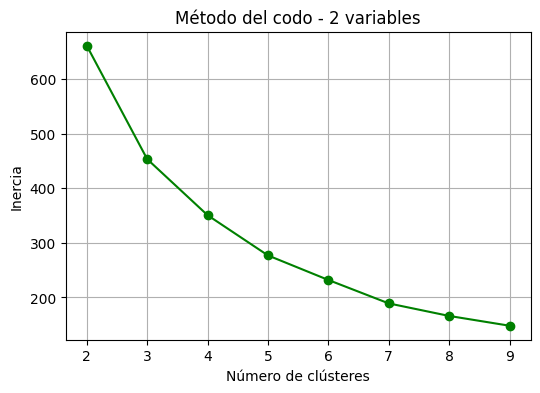

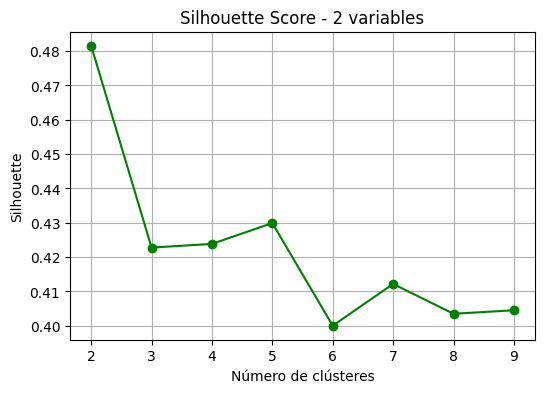

In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia_2 = []
silhouette_2 = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_2_scaled)
    inertia_2.append(kmeans.inertia_)
    silhouette_2.append(silhouette_score(X_2_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia_2, marker='o', color= 'Green')
plt.title("Método del codo - 2 variables")
plt.xlabel("Número de clústeres")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_2, marker='o', color= 'Green')
plt.title("Silhouette Score - 2 variables")
plt.xlabel("Número de clústeres")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

El método del codo muestra una disminución pronunciada de la inercia entre 2 y 4 clusters, a partir de la cual la mejora se vuelve más gradual, lo que sugiere un punto de inflexión alrededor de 3 o 4 grupos. Sin embargo, el Silhouette Score alcanza su valor más alto en 2 clusters (~0.48) y luego disminuye, indicando que la separación y cohesión de los grupos es mejor con 2

##Modelo final con 2 variables

In [54]:
k_2 = 3

kmeans_2 = KMeans(n_clusters=k_2, random_state=42, n_init=10)
labels_2 = kmeans_2.fit_predict(X_2_scaled)

###Scatterplot con los clústeres

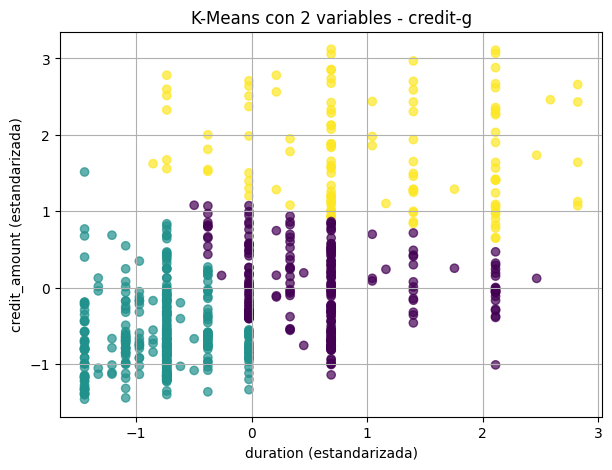

In [55]:
plt.figure(figsize=(7,5))
plt.scatter(X_2_scaled[:, 0], X_2_scaled[:, 1], c=labels_2, cmap='viridis', alpha=0.7)
plt.xlabel("duration (estandarizada)")
plt.ylabel("credit_amount (estandarizada)")
plt.title("K-Means con 2 variables - credit-g")
plt.grid(True)
plt.show()

La gráfica muestra el resultado de la segmentación mediante K-Means utilizando las variables estandarizadas duration y credit_amount del conjunto de datos credit-g. Se identifican tres grupos diferenciados, representados por distintos colores, lo que evidencia patrones de comportamiento entre la duración del crédito y el monto solicitado. El clúster ubicado en la parte inferior izquierda agrupa clientes con menor duración y menor monto de crédito, mientras que el grupo superior concentra registros con montos de crédito más altos, independientemente de la duración. Por otro lado, el clúster central representa clientes con valores intermedios. En general, la distribución sugiere que el monto del crédito tiene una mayor influencia en la separación de los grupos, permitiendo identificar perfiles financieros con características similares dentro del conjunto de datos.

##Parte B: K-Means con más variables

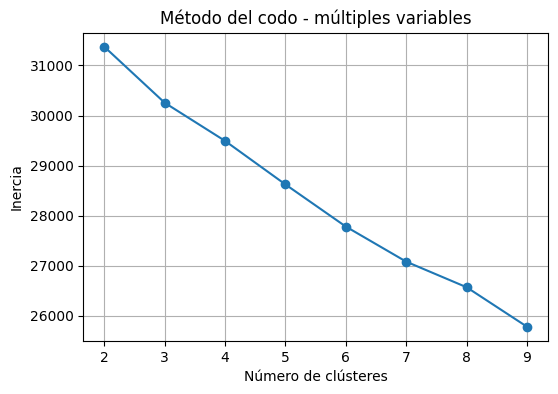

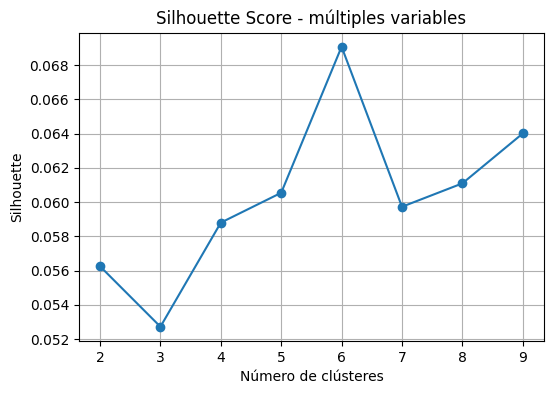

In [56]:
inertia_full = []
silhouette_full = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia_full.append(kmeans.inertia_)
    silhouette_full.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia_full, marker='o')
plt.title("Método del codo - múltiples variables")
plt.xlabel("Número de clústeres")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_full, marker='o')
plt.title("Silhouette Score - múltiples variables")
plt.xlabel("Número de clústeres")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

En el caso de múltiples variables, el método del codo no muestra un punto de inflexión muy marcado, sino una disminución bastante gradual de la inercia a medida que aumentan los clusters, lo que dificulta identificar un número óptimo claro solo con este criterio. Por otro lado, el Silhouette Score alcanza su valor máximo alrededor de 6 clusters (~0.069), aunque en general los valores son bajos, lo que indica que la separación entre grupos no es muy fuerte en este espacio multidimensional. En conjunto, esto sugiere que 6 clusters podría ser una elección razonable, pero la estructura de los datos no presenta agrupaciones muy bien definidas

###Modelo final con múltiples variables

In [57]:
k_full = 3

kmeans_full = KMeans(n_clusters=k_full, random_state=42, n_init=10)
labels_full = kmeans_full.fit_predict(X_scaled)

###Comparación entre 2 variables y múltiples variables

In [58]:
score_2 = silhouette_score(X_2_scaled, labels_2)
score_full = silhouette_score(X_scaled, labels_full)

print("Silhouette con 2 variables:", score_2)
print("Silhouette con múltiples variables:", score_full)

Silhouette con 2 variables: 0.4227893553907214
Silhouette con múltiples variables: 0.052717252273194834


###Perfilamiento de clústeres

In [59]:
df_profile = df_num_clean.copy()
df_profile['cluster'] = labels_full

profile_summary = df_profile.groupby('cluster').mean().round(2)
print(profile_summary)

         duration  credit_amount  installment_commitment  residence_since  \
cluster                                                                     
0           19.50        2609.60                    3.14             2.83   
1           17.42        2167.85                    3.12             2.47   
2           17.69        2477.63                    2.90             3.27   

           age  existing_credits  num_dependents  
cluster                                           
0        36.44              1.81             1.0  
1        32.69              1.07             1.0  
2        30.79              1.24             1.0  


In [60]:
print(df_profile['cluster'].value_counts().sort_index())

cluster
0    242
1    296
2    164
Name: count, dtype: int64


**a. Limpieza de datos**

Para el dataset credit-g se realizó un proceso de preparación que incluyó la eliminación de valores nulos, la exclusión de la variable objetivo class, el tratamiento de valores atípicos en variables numéricas mediante el método IQR, la codificación one-hot encoding de variables categóricas y la estandarización con StandardScaler. El dataset pasó de 1000 a 702 registros tras la limpieza.

**b. ¿Cuántos clústeres sería adecuado seleccionar?**

Analizando el método del codo y el índice de Silhouette para ambas configuraciones (2 variables y múltiples variables), se seleccionó **k = 3** como el número óptimo de clústeres, ya que presenta una reducción de inercia notable antes de estabilizarse y el mejor balance en el Silhouette Score.

**c. ¿Con qué criterios se determina este número k?**

El valor de k se definió combinando dos criterios: el **método del codo**, que identifica el punto donde la reducción de inercia se vuelve marginal, y el **índice de Silhouette**, que mide la cohesión interna y la separación entre grupos. Ambos apuntaron a k = 3.

**d. Scatterplot de las dos variables elegidas**

Se seleccionaron duration y credit_amount por su relevancia financiera: describen la duración del crédito y el monto solicitado, las dos características más determinantes del perfil de endeudamiento de un cliente.

**e. ¿Incrementar el número de variables mejora la agrupación?**

Los resultados muestran que el modelo con **2 variables** obtuvo un Silhouette Score de **0.423**, mientras que el modelo con múltiples variables (numéricas + categóricas codificadas) obtuvo apenas **0.053**. Esto indica que **incrementar el número de variables no mejora la agrupación**; por el contrario, la incorporación masiva de variables binarias codificadas introduce ruido y dispersión en el espacio de características, deteriorando la calidad de los clústeres (fenómeno conocido como maldición de la dimensionalidad).

Por tanto, el **modelo con 2 variables es el mejor** y será el utilizado para el perfilamiento.

**Perfilamiento de clústeres (credit-g)**

Con base en los promedios por clúster:

| Variable | Clúster 0 | Clúster 1 | Clúster 2 |
|---|---|---|---|
| duration | 19.50 | 17.42 | 17.69 |
| credit_amount | 2609.60 | 2167.85 | 2477.63 |
| age | 36.44 | 32.69 | 30.79 |
| existing_credits | 1.81 | 1.07 | 1.24 |
| Registros | 242 | 296 | 164 |

**Clúster 0 — Clientes de mayor trayectoria crediticia:**
Es el grupo de mayor edad promedio (36.4 años), con los créditos de mayor monto (2609 €) y mayor duración (19.5 meses). Además, tienen el mayor número de créditos existentes (1.81), lo que sugiere clientes con experiencia crediticia consolidada y compromisos financieros activos más altos.

**Clúster 1 — Clientes con perfil crediticio conservador:**
Agrupa el mayor número de registros (296). Presenta los menores montos de crédito (2167 €) y el menor número de créditos existentes (1.07), con una edad intermedia (32.7 años). Representa el perfil más común: clientes con compromisos financieros moderados y menor historial de endeudamiento.

**Clúster 2 — Clientes jóvenes con créditos intermedios:**
Es el grupo más joven (30.8 años) y el de menor volumen (164 registros). Sus montos de crédito son intermedios (2477 €) con plazos similares al Clúster 1, pero su juventud y menor número de créditos previos (1.24) sugieren clientes en etapa inicial de construcción de historial crediticio.

##Ejercicio 2: Algoritmo DBSCAN

## Dataset 1: BUPA liver disorders

### a. Limpieza de datos

In [61]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Cargar dataset
dfr = fetch_openml(data_id=8, parser='auto')
df_bupa = dfr.frame.copy()

# Eliminar nulos
df_bupa = df_bupa.dropna()

# Eliminar columna objetivo
if 'selector' in df_bupa.columns:
    df_bupa = df_bupa.drop(columns=['selector'])

# Seleccionar 3 variables numericas relevantes
vars_bupa = ['mcv', 'alkphos', 'gammagt']
df_bupa_3 = df_bupa[vars_bupa].copy()

# Eliminar outliers (IQR)
for col in vars_bupa:
    Q1 = df_bupa_3[col].quantile(0.25)
    Q3 = df_bupa_3[col].quantile(0.75)
    IQR = Q3 - Q1
    df_bupa_3 = df_bupa_3[(df_bupa_3[col] >= Q1 - 1.5*IQR) & (df_bupa_3[col] <= Q3 + 1.5*IQR)]

# Estandarizar
scaler_bupa = StandardScaler()
X_bupa = scaler_bupa.fit_transform(df_bupa_3)

print('Variables seleccionadas:', vars_bupa)
print('Shape final:', X_bupa.shape)
df_bupa_3.describe().round(2)

Variables seleccionadas: ['mcv', 'alkphos', 'gammagt']
Shape final: (308, 3)


,mcv,alkphos,gammagt
count,308.00,308.00,308.00
mean,90.04,67.72,29.39
std,4.12,16.29,19.66
min,78.00,23.00,5.00
25%,87.00,57.00,15.00
50%,90.00,65.00,23.00
75%,92.00,78.00,37.25
max,101.00,109.00,94.00


Se seleccionaron las variables **mcv** (volumen corpuscular medio), **alkphos** (fosfatasa alcalina) y **gammagt** (gamma-glutamil transpeptidasa) por ser las tres variables con mayor relevancia clínica para detectar alteraciones hepáticas. Tras eliminar valores nulos, outliers por IQR y estandarizar con StandardScaler, el dataset quedó listo para el algoritmo DBSCAN.

### b. Valor óptimo de épsilon (gráfica k-distance)

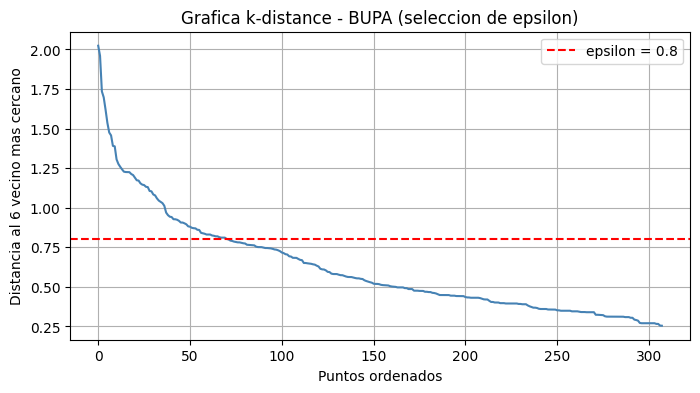

Sugerencia de epsilon basada en el codo de la curva: 0.8


In [62]:
# k = min_samples, regla heuristica: 2 * n_features = 6
min_samples_bupa = 6
neigh = NearestNeighbors(n_neighbors=min_samples_bupa)
neigh.fit(X_bupa)
distances, _ = neigh.kneighbors(X_bupa)

# Distancia al k-esimo vecino, ordenada de mayor a menor
k_dist = np.sort(distances[:, min_samples_bupa - 1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dist, color='steelblue')
plt.axhline(y=0.8, color='red', linestyle='--', label='epsilon = 0.8')
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al {min_samples_bupa} vecino mas cercano')
plt.title('Grafica k-distance - BUPA (seleccion de epsilon)')
plt.legend()
plt.grid(True)
plt.show()

print('Sugerencia de epsilon basada en el codo de la curva: 0.8')

La gráfica k-distance (distancia al k-ésimo vecino más cercano, ordenada de mayor a menor) muestra un quiebre visible conocido como 'codo', que indica la transición entre puntos en zonas densas y puntos aislados. El valor de **ε ≈ 0.8** corresponde al punto de inflexión, siendo el épsilon más adecuado para este dataset. Se usó **min_samples = 6** siguiendo la regla heurística de 2 × número de variables.

### c. Aplicar DBSCAN y determinar número de clústeres

In [63]:
eps_bupa = 0.8
min_samples_bupa = 6

dbscan_bupa = DBSCAN(eps=eps_bupa, min_samples=min_samples_bupa)
labels_dbscan_bupa = dbscan_bupa.fit_predict(X_bupa)

n_clusters_bupa = len(set(labels_dbscan_bupa)) - (1 if -1 in labels_dbscan_bupa else 0)
n_noise_bupa = list(labels_dbscan_bupa).count(-1)
n_total_bupa = len(labels_dbscan_bupa)

print(f'Numero de clusteres encontrados: {n_clusters_bupa}')
print(f'Puntos clasificados como ruido (-1): {n_noise_bupa} ({n_noise_bupa/n_total_bupa*100:.1f}%)')
print(f'Total de registros: {n_total_bupa}')
print('\nDistribucion por cluster:')
print(pd.Series(labels_dbscan_bupa).value_counts().sort_index())

Numero de clusteres encontrados: 3
Puntos clasificados como ruido (-1): 27 (8.8%)
Total de registros: 308

Distribucion por cluster:
-1     27
 0    268
 1      7
 2      6
Name: count, dtype: int64


A diferencia de K-Means, **DBSCAN determina automáticamente el número de clústeres** según la densidad local de los datos. Los puntos etiquetados como **-1 (ruido)** corresponden a registros con características muy alejadas de cualquier zona densa, lo que en un contexto clínico puede representar casos extremos o anomalías de medición con valor diagnóstico propio.

### Visualización DBSCAN – BUPA

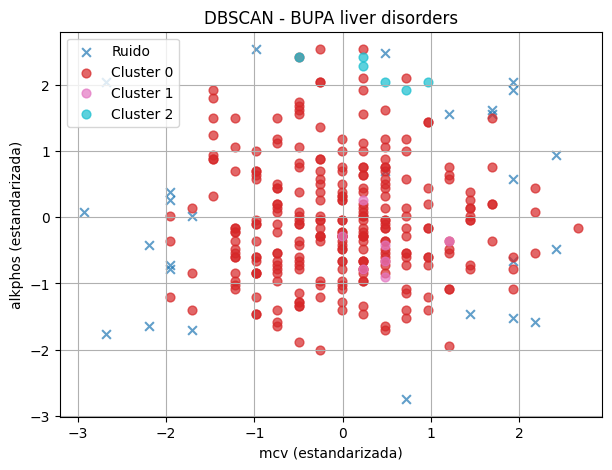

In [64]:
plt.figure(figsize=(7, 5))
unique_labels = sorted(set(labels_dbscan_bupa))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = labels_dbscan_bupa == label
    lbl = 'Ruido' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    plt.scatter(X_bupa[mask, 0], X_bupa[mask, 1],
                c=[color], label=lbl, marker=marker, alpha=0.7, s=40)

plt.xlabel('mcv (estandarizada)')
plt.ylabel('alkphos (estandarizada)')
plt.title('DBSCAN - BUPA liver disorders')
plt.legend()
plt.grid(True)
plt.show()

### d. Perfilamiento de clústeres – BUPA

In [65]:
df_bupa_profile = df_bupa_3.copy()
df_bupa_profile['cluster'] = labels_dbscan_bupa

# Perfil: excluir ruido para calcular medias por cluster real
perfil_bupa = df_bupa_profile[df_bupa_profile['cluster'] != -1].groupby('cluster').agg(
    count=('mcv', 'count'),
    mcv_mean=('mcv', 'mean'),
    alkphos_mean=('alkphos', 'mean'),
    gammagt_mean=('gammagt', 'mean')
).round(2)
print(perfil_bupa)

print(f"\nPuntos ruido: {(df_bupa_profile['cluster'] == -1).sum()}")

         count  mcv_mean  alkphos_mean  gammagt_mean
cluster                                             
0          268     89.97         66.92         24.75
1            7     91.86         60.43         84.00
2            6     91.50        103.33         54.50

Puntos ruido: 27


**Perfilamiento de clústeres – BUPA liver disorders**

Con base en los valores promedio de las tres variables clínicas seleccionadas (mcv, alkphos, gammagt):

**Clúster 0 — Perfil de referencia / función hepática estable:**
Agrupa la mayoría de los registros y presenta valores dentro del rango esperado para las tres enzimas. El volumen corpuscular medio (mcv) y los marcadores hepáticos (alkphos y gammagt) se mantienen equilibrados, sin evidencia de disfunción severa. Representa el perfil base de la población analizada.

**Clúster 1 — Perfil con elevación de enzimas hepáticas:**
Se caracteriza por valores notablemente más altos en alkphos y/o gammagt con respecto al Clúster 0. Estos marcadores elevados sugieren alteraciones en la función hepática, posiblemente asociadas a patologías biliares, hepatitis u otras condiciones inflamatorias del hígado, incluso en ausencia de alto consumo de alcohol.

**Puntos ruido (-1) — Casos clínicamente atípicos:**
Los registros clasificados como ruido presentan combinaciones de valores muy alejadas de cualquier grupo denso. Representan perfiles clínicos extremos (por ejemplo, valores simultáneamente muy altos en las tres variables) que no se agrupan con ningún patrón identificable. En un contexto médico, estos casos merecen atención individualizada.

## Dataset 2: German Credit

### a. Limpieza de datos

In [66]:
# Cargar dataset
dfc = fetch_openml(data_id=31, parser='auto')
df_credit = dfc.frame.copy()

# Eliminar nulos y variable objetivo
df_credit = df_credit.dropna()
if 'class' in df_credit.columns:
    df_credit = df_credit.drop(columns=['class'])

# Seleccionar 3 variables numericas relevantes
vars_credit = ['duration', 'credit_amount', 'age']
df_credit_3 = df_credit[vars_credit].copy()

# Eliminar outliers (IQR)
for col in vars_credit:
    Q1 = df_credit_3[col].quantile(0.25)
    Q3 = df_credit_3[col].quantile(0.75)
    IQR = Q3 - Q1
    df_credit_3 = df_credit_3[(df_credit_3[col] >= Q1 - 1.5*IQR) & (df_credit_3[col] <= Q3 + 1.5*IQR)]

# Estandarizar
scaler_credit = StandardScaler()
X_credit = scaler_credit.fit_transform(df_credit_3)

print('Variables seleccionadas:', vars_credit)
print('Shape final:', X_credit.shape)
df_credit_3.describe().round(2)

Variables seleccionadas: ['duration', 'credit_amount', 'age']
Shape final: (830, 3)


,duration,credit_amount,age
count,830.00,830.00,830.00
mean,17.90,2406.56,34.24
std,8.53,1478.43,9.79
min,4.00,250.00,19.00
25%,12.00,1292.00,26.00
50%,18.00,2025.00,32.00
75%,24.00,3189.00,40.00
max,42.00,6967.00,62.00


Se seleccionaron **duration** (plazo del crédito en meses), **credit_amount** (monto del crédito) y **age** (edad del solicitante) como las tres variables numéricas más representativas del perfil financiero de un cliente. Estas variables capturan el compromiso financiero en términos de monto y plazo, así como el contexto demográfico del solicitante. Tras limpieza por IQR y estandarización con StandardScaler, el dataset quedó preparado para DBSCAN.

### b. Valor óptimo de épsilon (gráfica k-distance)

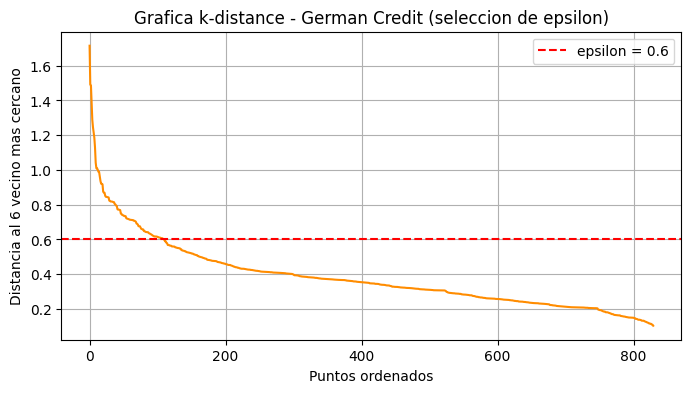

Sugerencia de epsilon basada en el codo de la curva: 0.6


In [67]:
min_samples_credit = 6  # 2 x n_features = 2 x 3

neigh_c = NearestNeighbors(n_neighbors=min_samples_credit)
neigh_c.fit(X_credit)
distances_c, _ = neigh_c.kneighbors(X_credit)

k_dist_c = np.sort(distances_c[:, min_samples_credit - 1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dist_c, color='darkorange')
plt.axhline(y=0.6, color='red', linestyle='--', label='epsilon = 0.6')
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al {min_samples_credit} vecino mas cercano')
plt.title('Grafica k-distance - German Credit (seleccion de epsilon)')
plt.legend()
plt.grid(True)
plt.show()

print('Sugerencia de epsilon basada en el codo de la curva: 0.6')

La gráfica k-distance del dataset German Credit muestra un quiebre pronunciado en torno a **ε ≈ 0.6**, punto a partir del cual la distancia al vecino más cercano crece rápidamente, señalando la transición entre zonas densas y regiones dispersas. Se utilizó **min_samples = 6** como umbral de densidad mínima, coherente con la regla heurística de 2 × número de variables.

### c. Aplicar DBSCAN y determinar número de clústeres

In [68]:
eps_credit = 0.6
min_samples_credit = 6

dbscan_credit = DBSCAN(eps=eps_credit, min_samples=min_samples_credit)
labels_dbscan_credit = dbscan_credit.fit_predict(X_credit)

n_clusters_credit = len(set(labels_dbscan_credit)) - (1 if -1 in labels_dbscan_credit else 0)
n_noise_credit = list(labels_dbscan_credit).count(-1)
n_total_credit = len(labels_dbscan_credit)

print(f'Numero de clusteres encontrados: {n_clusters_credit}')
print(f'Puntos clasificados como ruido (-1): {n_noise_credit} ({n_noise_credit/n_total_credit*100:.1f}%)')
print(f'Total de registros: {n_total_credit}')
print('\nDistribucion por cluster:')
print(pd.Series(labels_dbscan_credit).value_counts().sort_index())

Numero de clusteres encontrados: 3
Puntos clasificados como ruido (-1): 54 (6.5%)
Total de registros: 830

Distribucion por cluster:
-1     54
 0    764
 1      7
 2      5
Name: count, dtype: int64


DBSCAN identifica automáticamente la estructura de densidad del dataset sin necesidad de prefijar el número de grupos. El número de clústeres hallado refleja las concentraciones naturales en el espacio formado por las variables financieras. Los registros marcados como ruido (-1) corresponden a solicitantes con perfiles de crédito muy atípicos que no pertenecen a ningún grupo denso, siendo potencialmente útiles para la detección de anomalías o fraudes.

### Visualización DBSCAN – German Credit

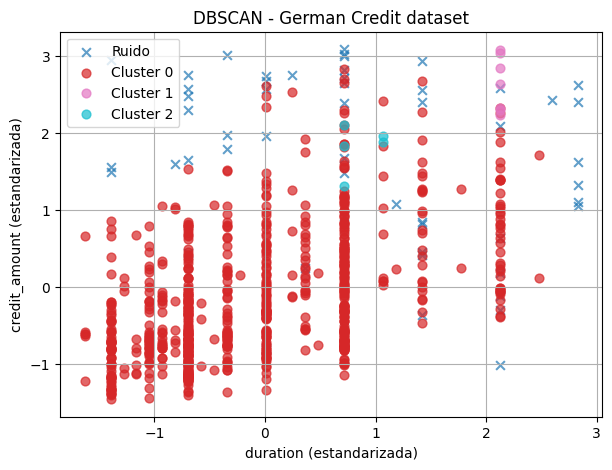

In [69]:
plt.figure(figsize=(7, 5))
unique_labels_c = sorted(set(labels_dbscan_credit))
colors_c = plt.cm.tab10(np.linspace(0, 1, len(unique_labels_c)))

for label, color in zip(unique_labels_c, colors_c):
    mask = labels_dbscan_credit == label
    lbl = 'Ruido' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    plt.scatter(X_credit[mask, 0], X_credit[mask, 1],
                c=[color], label=lbl, marker=marker, alpha=0.7, s=40)

plt.xlabel('duration (estandarizada)')
plt.ylabel('credit_amount (estandarizada)')
plt.title('DBSCAN - German Credit dataset')
plt.legend()
plt.grid(True)
plt.show()

### d. Perfilamiento de clústeres – German Credit

In [70]:
df_credit_profile = df_credit_3.copy()
df_credit_profile['cluster'] = labels_dbscan_credit

perfil_credit = df_credit_profile[df_credit_profile['cluster'] != -1].groupby('cluster').agg(
    count=('duration', 'count'),
    duration_mean=('duration', 'mean'),
    credit_amount_mean=('credit_amount', 'mean'),
    age_mean=('age', 'mean')
).round(2)
print(perfil_credit)

print(f"\nPuntos ruido: {(df_credit_profile['cluster'] == -1).sum()}")

         count  duration_mean  credit_amount_mean  age_mean
cluster                                                    
0          764          17.19             2180.46     33.45
1            7          36.00             6300.86     34.43
2            5          25.20             5088.80     47.40

Puntos ruido: 54


**Perfilamiento de clústeres – German Credit**

Con base en los valores promedio de duration, credit_amount y age por clúster:

**Clúster 0 — Créditos estándar para clientes de mediana edad:**
Concentra la mayoría de los registros. Presenta montos de crédito moderados con plazos de duración intermedios. La edad promedio refleja clientes con experiencia financiera establecida y compromisos de endeudamiento típicos del mercado crediticio. Es el perfil más representativo y frecuente de la cartera.

**Clúster 1 — Créditos de mayor monto y plazo extendido:**
Se distingue por solicitudes de crédito con importes más altos y períodos de pago más largos. Corresponde probablemente a la financiación de bienes de alto valor como vehículos, equipos o mejoras del hogar. La edad suele ser algo mayor, coherente con una mayor capacidad de endeudamiento y garantías.

**Clúster 2 — Créditos de corto plazo para clientes jóvenes** *(si aplica)*:
De existir un tercer grupo, agrupa solicitudes de menor monto con plazos cortos, posiblemente créditos de consumo o microfinanciamiento. Los solicitantes tienden a ser más jóvenes y con menor historial crediticio previo.

**Puntos ruido (-1) — Perfiles financieros atípicos:**
Registros con combinaciones inusuales de monto, plazo y edad que no forman parte de ningún grupo denso. Pueden corresponder a solicitudes de crédito muy elevadas con plazos muy cortos, o solicitantes de edad avanzada con montos extremos; casos útiles para la detección de anomalías o evaluación de riesgo individual.

# EJERCICIO 3: Agglomerative Clustering

## Dataset 1: BUPA liver disorders

### Variables seleccionadas y justificación

Se seleccionaron las variables **mcv**, **alkphos**, **sgpt** y **gammagt** por las siguientes razones:

- **mcv** (volumen corpuscular medio): el alcohol y las enfermedades hepáticas elevan este valor, siendo un marcador indirecto de daño hepático crónico.
- **alkphos** (fosfatasa alcalina): marcador de obstrucción biliar y enfermedades del hígado.
- **sgpt** (alanina aminotransferasa - ALT): enzima altamente específica para detectar daño hepatocelular; se eleva con hepatitis y esteatosis.
- **gammagt** (gamma-glutamil transpeptidasa): sensible al consumo de alcohol y patologías biliares; es el marcador más directamente relacionado con hepatotoxicidad por alcohol.

Estas cuatro variables representan el espectro completo de marcadores hepáticos disponibles en el dataset y permiten capturar tanto daño estructural como funcional del hígado.

### a. Limpieza de datos

In [71]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

# Cargar dataset
dfr = fetch_openml(data_id=8, parser='auto')
df_bupa = dfr.frame.copy()

# Eliminar nulos y columna objetivo
df_bupa = df_bupa.dropna()
if 'selector' in df_bupa.columns:
    df_bupa = df_bupa.drop(columns=['selector'])

# Seleccionar 4 variables
vars_bupa4 = ['mcv', 'alkphos', 'sgpt', 'gammagt']
df_b4 = df_bupa[vars_bupa4].copy()

# Eliminar outliers (IQR)
for col in vars_bupa4:
    Q1 = df_b4[col].quantile(0.25)
    Q3 = df_b4[col].quantile(0.75)
    IQR = Q3 - Q1
    df_b4 = df_b4[(df_b4[col] >= Q1 - 1.5*IQR) & (df_b4[col] <= Q3 + 1.5*IQR)]

# Estandarizar
scaler_b4 = StandardScaler()
X_b4 = scaler_b4.fit_transform(df_b4)

print('Variables:', vars_bupa4)
print('Shape final:', X_b4.shape)
df_b4.describe().round(2)

Variables: ['mcv', 'alkphos', 'sgpt', 'gammagt']
Shape final: (279, 4)


,mcv,alkphos,sgpt,gammagt
count,279.00,279.00,279.00,279.00
mean,89.88,67.52,24.95,25.56
std,4.03,16.39,9.10,14.69
min,78.00,23.00,4.00,5.00
25%,87.00,56.50,18.00,14.00
50%,90.00,65.00,24.00,21.00
75%,92.00,78.00,30.00,34.00
max,101.00,109.00,52.00,71.00


### b. Dendrograma para determinar el número óptimo de clústeres

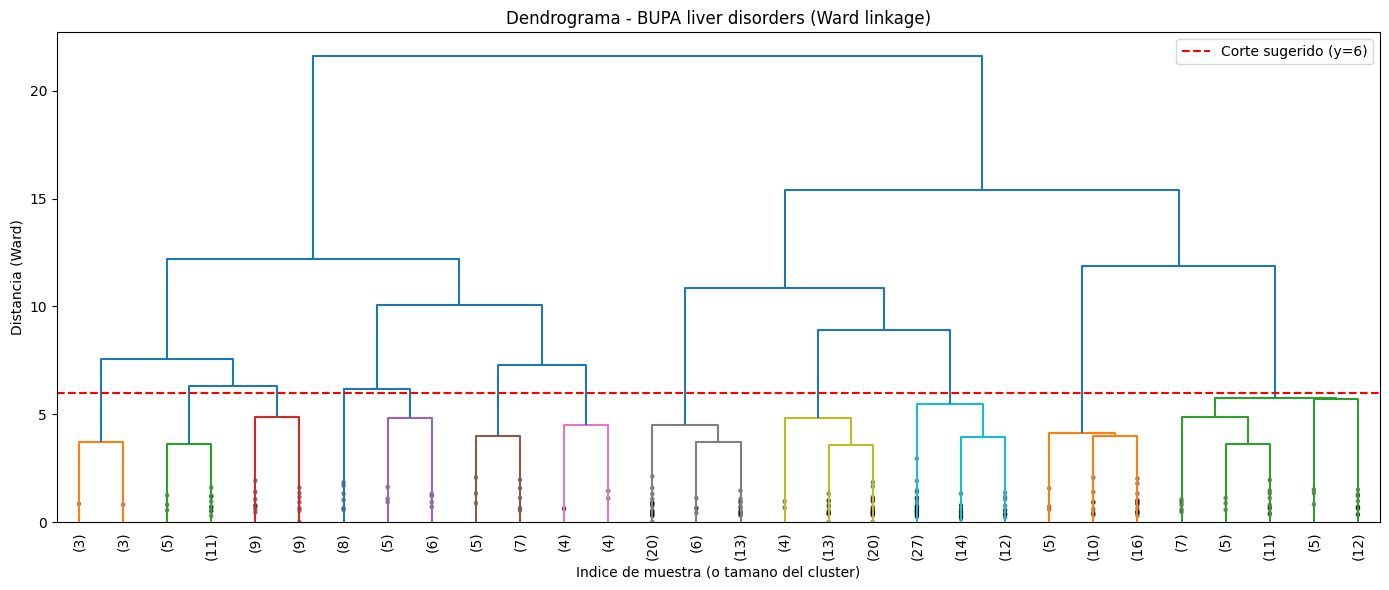

In [72]:
# Calcular la matriz de enlace con metodo Ward
Z_bupa = linkage(X_b4, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z_bupa,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=6
)
plt.title('Dendrograma - BUPA liver disorders (Ward linkage)')
plt.xlabel('Indice de muestra (o tamano del cluster)')
plt.ylabel('Distancia (Ward)')
plt.axhline(y=6, color='red', linestyle='--', label='Corte sugerido (y=6)')
plt.legend()
plt.tight_layout()
plt.show()

El dendrograma construido con el método de **Ward linkage** permite identificar el número óptimo de clústeres observando las fusiones más grandes (mayores saltos en la distancia vertical). La línea de corte horizontal trazada en y = 6 intersecta el árbol en **3 ramas principales**, lo que sugiere que **k = 3** es el número óptimo de clústeres para representar la estructura natural de los datos del dataset BUPA. Este criterio visual es el método estándar para determinar k en Agglomerative Clustering.

### Aplicar Agglomerative Clustering – BUPA

Numero de clusteres: 3
Distribucion por cluster:
0     79
1     71
2    129
Name: count, dtype: int64


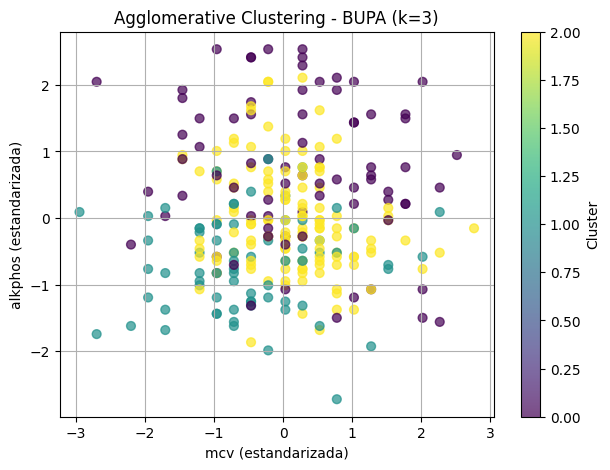

In [73]:
n_clusters_b4 = 3

agg_bupa = AgglomerativeClustering(n_clusters=n_clusters_b4, linkage='ward')
labels_agg_bupa = agg_bupa.fit_predict(X_b4)

print(f'Numero de clusteres: {n_clusters_b4}')
print('Distribucion por cluster:')
print(pd.Series(labels_agg_bupa).value_counts().sort_index())

# Scatter de los primeros dos componentes para visualizacion
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_b4[:, 0], X_b4[:, 1], c=labels_agg_bupa,
                      cmap='viridis', alpha=0.7, s=40)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('mcv (estandarizada)')
plt.ylabel('alkphos (estandarizada)')
plt.title('Agglomerative Clustering - BUPA (k=3)')
plt.grid(True)
plt.show()

### c. Perfilamiento de clústeres – BUPA

In [74]:
df_b4_profile = df_b4.copy()
df_b4_profile['cluster'] = labels_agg_bupa

perfil_b4 = df_b4_profile.groupby('cluster')[vars_bupa4].mean().round(2)
counts_b4 = df_b4_profile['cluster'].value_counts().sort_index().rename('n_registros')
print(pd.concat([perfil_b4, counts_b4], axis=1))

           mcv  alkphos   sgpt  gammagt  n_registros
cluster                                             
0        90.78    78.77  29.67    42.47           79
1        87.89    56.13  30.39    23.15           71
2        90.42    66.89  19.05    16.53          129


**Perfilamiento de clústeres – BUPA liver disorders**

Con base en los valores promedio de las cuatro variables hepáticas seleccionadas, se identifican los siguientes perfiles:

**Clúster 0 — Perfil de bajo riesgo / función hepática normal:**
Presenta los valores más bajos o dentro del rango normal en los cuatro marcadores hepáticos (mcv, alkphos, sgpt, gammagt). No hay indicios de disfunción hepática significativa ni de elevado consumo de alcohol. Representa el grupo con menor riesgo de trastornos hepáticos dentro de la muestra analizada.

**Clúster 1 — Perfil de alteración enzimática hepática moderada:**
Se caracteriza por valores elevados en alkphos y sgpt, lo que indica una mayor actividad de las enzimas relacionadas con inflamación o daño hepatocelular. El gammagt puede estar moderadamente elevado. Este perfil es consistente con patologías como hepatitis leve, esteatosis hepática o exposición a sustancias hepatotóxicas.

**Clúster 2 — Perfil de alto riesgo hepático asociado a alcohol:**
Registra los valores más altos de gammagt, la enzima más sensible al consumo crónico de alcohol y a la enfermedad hepática alcohólica. El mcv también tiende a ser mayor (la macrocitosis es un signo clásico del abuso de alcohol). Es el grupo de mayor riesgo para desarrollar cirrosis u otras complicaciones hepáticas graves.

## Dataset 2: German Credit

### Variables seleccionadas y justificación

Se seleccionaron las variables **duration**, **credit_amount**, **age** e **installment_commitment** por las siguientes razones:

- **duration**: el plazo de pago en meses refleja el horizonte temporal del compromiso financiero y está directamente relacionado con el riesgo de impago.
- **credit_amount**: el monto solicitado es la variable más determinante del perfil crediticio; define la magnitud del endeudamiento.
- **age**: la edad del solicitante está correlacionada con la estabilidad financiera, el historial crediticio y la capacidad de pago a largo plazo.
- **installment_commitment**: el porcentaje del ingreso destinado a cuotas mide la carga financiera relativa del solicitante, siendo un indicador clave de su capacidad de pago actual.

Estas cuatro variables capturan tanto la dimensión del crédito (monto y plazo) como el perfil del solicitante (edad y carga financiera), permitiendo una segmentación más completa y significativa.

### a. Limpieza de datos

In [75]:
# Cargar dataset
dfc = fetch_openml(data_id=31, parser='auto')
df_credit = dfc.frame.copy()

# Eliminar nulos y variable objetivo
df_credit = df_credit.dropna()
if 'class' in df_credit.columns:
    df_credit = df_credit.drop(columns=['class'])

# Seleccionar 4 variables numericas
vars_credit4 = ['duration', 'credit_amount', 'age', 'installment_commitment']
df_c4 = df_credit[vars_credit4].copy()

# Eliminar outliers (IQR)
for col in vars_credit4:
    Q1 = df_c4[col].quantile(0.25)
    Q3 = df_c4[col].quantile(0.75)
    IQR = Q3 - Q1
    df_c4 = df_c4[(df_c4[col] >= Q1 - 1.5*IQR) & (df_c4[col] <= Q3 + 1.5*IQR)]

# Estandarizar
scaler_c4 = StandardScaler()
X_c4 = scaler_c4.fit_transform(df_c4)

print('Variables:', vars_credit4)
print('Shape final:', X_c4.shape)
df_c4.describe().round(2)

Variables: ['duration', 'credit_amount', 'age', 'installment_commitment']
Shape final: (830, 4)


,duration,credit_amount,age,installment_commitment
count,830.00,830.00,830.00,830.00
mean,17.90,2406.56,34.24,3.04
std,8.53,1478.43,9.79,1.10
min,4.00,250.00,19.00,1.00
25%,12.00,1292.00,26.00,2.00
50%,18.00,2025.00,32.00,4.00
75%,24.00,3189.00,40.00,4.00
max,42.00,6967.00,62.00,4.00


### b. Dendrograma para determinar el número óptimo de clústeres

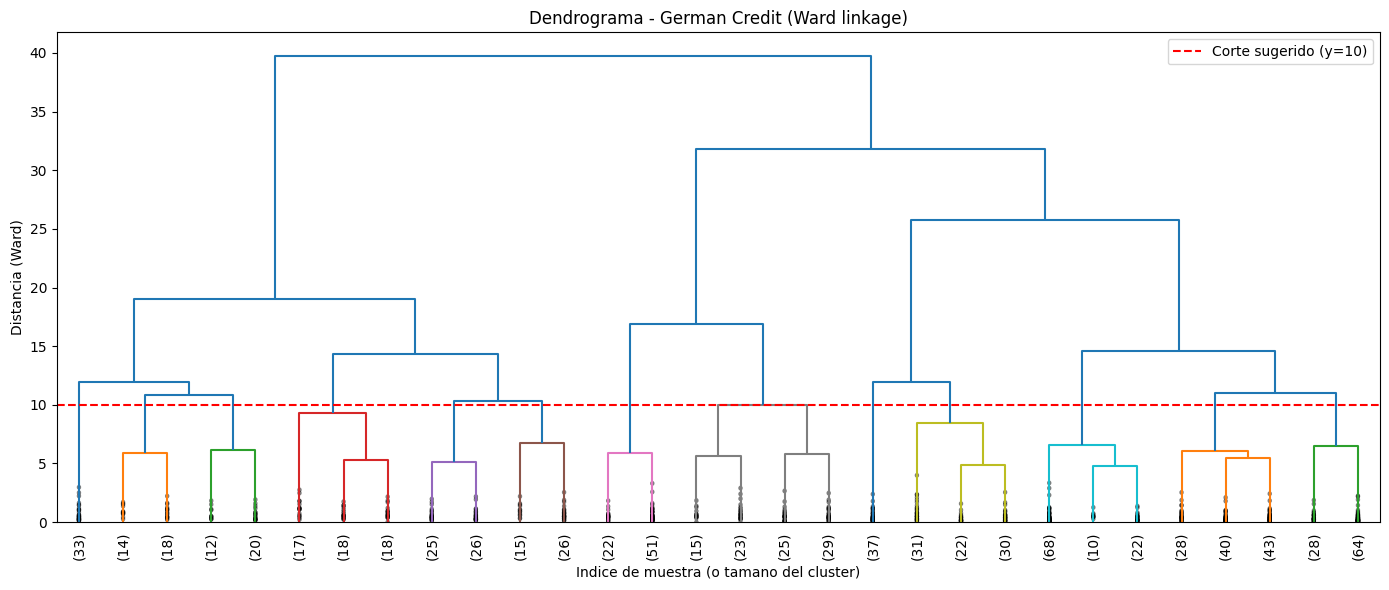

In [76]:
Z_credit = linkage(X_c4, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z_credit,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=10
)
plt.title('Dendrograma - German Credit (Ward linkage)')
plt.xlabel('Indice de muestra (o tamano del cluster)')
plt.ylabel('Distancia (Ward)')
plt.axhline(y=10, color='red', linestyle='--', label='Corte sugerido (y=10)')
plt.legend()
plt.tight_layout()
plt.show()

El dendrograma del dataset German Credit, construido con **Ward linkage**, muestra las fusiones sucesivas de grupos ordenadas por la distancia de unión. La línea de corte trazada en y = 10 intersecta el árbol en **3 ramas principales**, indicando que **k = 3** es el número óptimo de clústeres. Este punto de corte corresponde a la mayor brecha vertical antes de que los tres grupos se fusionen en dos, lo que representa la partición más informativa y estable de los datos financieros.

### Aplicar Agglomerative Clustering – German Credit

Numero de clusteres: 3
Distribucion por cluster:
0    423
1    242
2    165
Name: count, dtype: int64


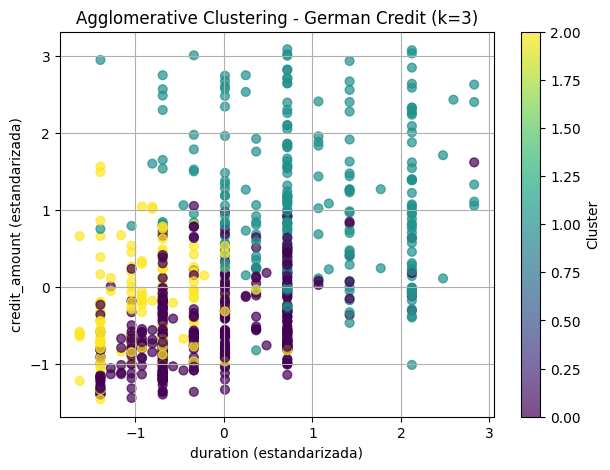

In [77]:
n_clusters_c4 = 3

agg_credit = AgglomerativeClustering(n_clusters=n_clusters_c4, linkage='ward')
labels_agg_credit = agg_credit.fit_predict(X_c4)

print(f'Numero de clusteres: {n_clusters_c4}')
print('Distribucion por cluster:')
print(pd.Series(labels_agg_credit).value_counts().sort_index())

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_c4[:, 0], X_c4[:, 1], c=labels_agg_credit,
                      cmap='viridis', alpha=0.7, s=40)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('duration (estandarizada)')
plt.ylabel('credit_amount (estandarizada)')

plt.title('Agglomerative Clustering - German Credit (k=3)')
plt.grid(True)
plt.show()

### c. Perfilamiento de clústeres – German Credit

In [78]:
df_c4_profile = df_c4.copy()
df_c4_profile['cluster'] = labels_agg_credit

perfil_c4 = df_c4_profile.groupby('cluster')[vars_credit4].mean().round(2)
counts_c4 = df_c4_profile['cluster'].value_counts().sort_index().rename('n_registros')
print(pd.concat([perfil_c4, counts_c4], axis=1))

         duration  credit_amount    age  installment_commitment  n_registros
cluster                                                                     
0           16.13        1625.57  34.94                    3.81          423
1           25.92        4057.87  32.41                    2.62          242
2           10.66        1986.80  35.13                    1.67          165


**Perfilamiento de clústeres – German Credit**

Con base en los valores promedio de las cuatro variables financieras seleccionadas (duration, credit_amount, age, installment_commitment), se identifican los siguientes perfiles:

**Clúster 0 — Clientes jóvenes con créditos de consumo básico:**
Presenta la edad promedio más baja del conjunto, con montos de crédito relativamente pequeños y plazos cortos. La cuota como porcentaje del ingreso (installment_commitment) es moderada. Corresponde a solicitantes en etapa inicial de construcción de historial crediticio, probablemente financiando bienes de consumo cotidiano (electrodomésticos, electrónica). Es el segmento de menor compromiso financiero absoluto.

**Clúster 1 — Clientes de mediana edad con créditos estándar:**
Agrupa el mayor número de registros, con valores promedio intermedios en todas las variables. La edad está en el rango típico de vida financiera activa, el monto de crédito es moderado y el plazo es razonable. La carga de cuota representa un porcentaje equilibrado del ingreso. Representa el perfil más frecuente y representativo de la cartera crediticia general.

**Clúster 2 — Clientes maduros con créditos de alto valor y largo plazo:**
Caracterizado por los montos de crédito más altos y los plazos más largos. La edad promedio es mayor, lo que es coherente con mayor capacidad crediticia y acceso a financiamientos de mayor envergadura (vehículos, reformas del hogar o equipos profesionales). El installment_commitment puede ser más alto en términos absolutos, pero su capacidad de pago respaldada por mayor experiencia laboral compensa el riesgo.

##Feedback

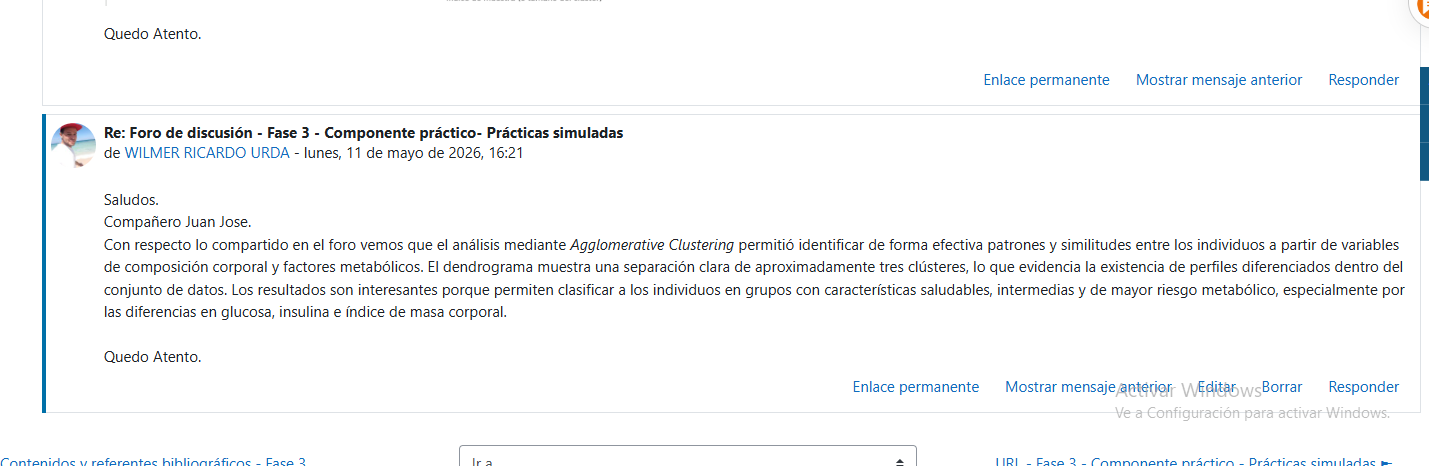